In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(parallel)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [3]:
load("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_prediction_spearman—_select.Rdata")

In [2]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
#basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ] None missing value
dim(basicPhenos)

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 527  18

In [5]:
microbiome <- read.csv("/vol/projects/yzhang/500FG_aging/input/microbiome/microbiome_rank_normalized.csv",row.names=1)
head(microbiome)
dim(microbiome)
any(is.na(microbiome))

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-0.5042045,-0.4060500,0.60040659,-0.1838672,0.3240735,0.5448127,1.204917,-0.5379838,0.1420268,-0.02359398,⋯,-0.04720111,-0.94260623,0.1122966,0.5042045,0.7330476,0.1599237,-1.0288942,-0.710092045,-0.005897983,-0.2018935
HV028,0.1241753,0.1599237,0.43180609,-0.5109133,0.3490406,1.1808884,-1.413029,0.4513120,-0.8542957,-0.63610823,⋯,-1.42921942,-1.24232236,-0.4578519,-1.7645046,-0.6726398,-0.4060500,0.7025232,0.906434569,-0.286993043,0.3616052
HV029,-1.3817163,0.6506164,0.07083458,-0.2808525,-1.6391767,-0.2747225,1.965021,-1.5547736,-0.1182339,1.57483681,⋯,-1.24232236,-1.01893191,0.3054808,-0.3427790,-1.9650214,-1.4627733,2.1049677,0.005897983,-1.281551566,1.2296625
HV030,1.6861615,0.6289042,-0.19587771,-0.3996535,-0.5654544,-1.9258937,1.737194,-0.4447913,-0.3178638,0.60748452,⋯,-0.10043372,-0.05310649,0.6949944,-0.2563934,0.5723885,-1.1575228,1.1236148,0.756396068,-0.035395082,-1.7371940
HV031,1.6169811,1.2551846,-1.96502137,3.0416387,-1.3665554,0.1898690,-1.192817,1.5353174,1.1125951,0.40604997,⋯,0.91536509,-0.30548079,1.1017089,-0.1539527,0.8542957,0.3490406,0.5176451,-0.687504754,-0.256393432,-1.8895100
HV033,0.7253533,0.7100920,-0.69499438,-0.1420268,-0.1898690,-0.6145930,-1.322859,-0.6361082,0.1182339,-0.42534083,⋯,1.26825785,1.20491713,0.7563961,1.6391767,-0.8458309,-0.2808525,-0.1539527,0.100433721,1.351702240,-0.7177018


[1] 425 524

[1] FALSE

In [3]:
# microbiome <- read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_microbiome_pathways.txt", header = TRUE, sep = "", stringsAsFactors = FALSE)
# head(microbiome)
# dim(microbiome)
# any(is.na(microbiome))

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV531,105.9234,1709.793,4675.400,5350.948,142.5939,340.8828,101.03553,7878.11010,2547.691,122.1253,⋯,2615.627,106.7624,740.3582,145.2831,155.5064,204.7743,108.2518,0.0000,101.0818,2368.077
HV532,111.9052,2419.922,4742.467,5256.545,156.8008,1199.9141,116.37555,-650.90151,2676.461,107.1662,⋯,2459.579,111.9338,869.5886,508.5559,175.2812,298.9233,106.1919,0.0000,101.7388,2339.662
HV533,104.1252,3060.407,5050.507,5322.419,133.2463,2272.5025,99.44764,260.94155,2133.189,180.5580,⋯,1856.333,102.0389,585.4480,127.1976,129.4395,309.5235,106.8537,0.0000,100.7286,2613.771
HV534,103.8862,2039.811,5783.870,4835.498,176.4493,2701.3976,140.63273,6826.20960,1886.170,104.7976,⋯,1591.879,103.7443,802.2063,642.2370,123.8644,302.2354,0.0000,0.0000,102.4864,1728.282
HV305,110.1563,2617.544,4911.302,5326.415,133.8508,2103.9627,102.36591,714.51235,2290.786,149.5210,⋯,2175.147,103.0316,648.8517,151.3800,164.2915,480.1675,103.7260,100.9269,101.2753,1926.143
HV352,104.4967,3421.462,4586.430,5412.430,118.0942,2519.6043,101.28686,41.95943,2307.831,171.1047,⋯,2719.372,107.6621,1607.8486,130.8270,119.8968,109.4525,110.1730,100.8376,101.2423,2123.012


[1] 425 524

[1] FALSE

In [6]:
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/multi-omics_common_sample_without_microbiome.rds") 
common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples_nogenptype.rds")
microbiome <- microbiome[common_samples, , drop = FALSE]
dim(microbiome)
head(microbiome)

[1] 186 524

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-0.5042045,-0.4060500,0.60040659,-0.1838672,0.3240735,0.5448127,1.204917,-0.5379838,0.1420268,-0.02359398,⋯,-0.04720111,-0.94260623,0.1122966,0.5042045,0.7330476,0.1599237,-1.0288942,-0.710092045,-0.005897983,-0.2018935
HV028,0.1241753,0.1599237,0.43180609,-0.5109133,0.3490406,1.1808884,-1.413029,0.4513120,-0.8542957,-0.63610823,⋯,-1.42921942,-1.24232236,-0.4578519,-1.7645046,-0.6726398,-0.4060500,0.7025232,0.906434569,-0.286993043,0.3616052
HV029,-1.3817163,0.6506164,0.07083458,-0.2808525,-1.6391767,-0.2747225,1.965021,-1.5547736,-0.1182339,1.57483681,⋯,-1.24232236,-1.01893191,0.3054808,-0.3427790,-1.9650214,-1.4627733,2.1049677,0.005897983,-1.281551566,1.2296625
HV030,1.6861615,0.6289042,-0.19587771,-0.3996535,-0.5654544,-1.9258937,1.737194,-0.4447913,-0.3178638,0.60748452,⋯,-0.10043372,-0.05310649,0.6949944,-0.2563934,0.5723885,-1.1575228,1.1236148,0.756396068,-0.035395082,-1.7371940
HV031,1.6169811,1.2551846,-1.96502137,3.0416387,-1.3665554,0.1898690,-1.192817,1.5353174,1.1125951,0.40604997,⋯,0.91536509,-0.30548079,1.1017089,-0.1539527,0.8542957,0.3490406,0.5176451,-0.687504754,-0.256393432,-1.8895100
HV033,0.7253533,0.7100920,-0.69499438,-0.1420268,-0.1898690,-0.6145930,-1.322859,-0.6361082,0.1182339,-0.42534083,⋯,1.26825785,1.20491713,0.7563961,1.6391767,-0.8458309,-0.2808525,-0.1539527,0.100433721,1.351702240,-0.7177018


In [7]:
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(microbiome), basicPhenos$ID_500fg) 
length(idx) #458samples
microbiome_filter = microbiome[which(rownames(microbiome) %in% idx),]
head(microbiome_filter)  #458samples,1596 metabolite
dim(microbiome_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(microbiome_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(microbiome_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(microbiome))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples

[1] 186

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,COBALSYN.PWY..adenosylcobalamin.salvage.from.cobinamide.I,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-0.5042045,-0.4060500,0.60040659,-0.1838672,0.3240735,0.5448127,1.204917,-0.5379838,0.1420268,-0.02359398,⋯,-0.04720111,-0.94260623,0.1122966,0.5042045,0.7330476,0.1599237,-1.0288942,-0.710092045,-0.005897983,-0.2018935
HV028,0.1241753,0.1599237,0.43180609,-0.5109133,0.3490406,1.1808884,-1.413029,0.4513120,-0.8542957,-0.63610823,⋯,-1.42921942,-1.24232236,-0.4578519,-1.7645046,-0.6726398,-0.4060500,0.7025232,0.906434569,-0.286993043,0.3616052
HV029,-1.3817163,0.6506164,0.07083458,-0.2808525,-1.6391767,-0.2747225,1.965021,-1.5547736,-0.1182339,1.57483681,⋯,-1.24232236,-1.01893191,0.3054808,-0.3427790,-1.9650214,-1.4627733,2.1049677,0.005897983,-1.281551566,1.2296625
HV030,1.6861615,0.6289042,-0.19587771,-0.3996535,-0.5654544,-1.9258937,1.737194,-0.4447913,-0.3178638,0.60748452,⋯,-0.10043372,-0.05310649,0.6949944,-0.2563934,0.5723885,-1.1575228,1.1236148,0.756396068,-0.035395082,-1.7371940
HV031,1.6169811,1.2551846,-1.96502137,3.0416387,-1.3665554,0.1898690,-1.192817,1.5353174,1.1125951,0.40604997,⋯,0.91536509,-0.30548079,1.1017089,-0.1539527,0.8542957,0.3490406,0.5176451,-0.687504754,-0.256393432,-1.8895100
HV033,0.7253533,0.7100920,-0.69499438,-0.1420268,-0.1898690,-0.6145930,-1.322859,-0.6361082,0.1182339,-0.42534083,⋯,1.26825785,1.20491713,0.7563961,1.6391767,-0.8458309,-0.2808525,-0.1539527,0.100433721,1.351702240,-0.7177018


[1] 186 524

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
2,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
3,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
4,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
5,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1
6,207,HV054,male,18,182,64,19.32134,Married,University student,European,Never,No,No,30,9,270,2013,Group 1


[1] 186  18

[1] 1

[1] 186

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
39,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
164,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
127,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4
145,197,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013,Group 4
64,181,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013,Group 2
59,162,HV033,female,21,165,63,23.14050,Married,University student,European,Rarely,No,No,14,10,284,2013,Group 2


[1] 186  18

In [8]:
microbiome_age <- cbind(microbiome_filter, Age = basicPhenos_filter_match$Age)
head(microbiome_age)
dim(microbiome_age)

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,PWY.822..fructan.biosynthesis,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,-0.5042045,-0.4060500,0.60040659,-0.1838672,0.3240735,0.5448127,1.204917,-0.5379838,0.1420268,-0.02359398,⋯,-0.94260623,0.1122966,0.5042045,0.7330476,0.1599237,-1.0288942,-0.710092045,-0.005897983,-0.2018935,20
HV028,0.1241753,0.1599237,0.43180609,-0.5109133,0.3490406,1.1808884,-1.413029,0.4513120,-0.8542957,-0.63610823,⋯,-1.24232236,-0.4578519,-1.7645046,-0.6726398,-0.4060500,0.7025232,0.906434569,-0.286993043,0.3616052,29
HV029,-1.3817163,0.6506164,0.07083458,-0.2808525,-1.6391767,-0.2747225,1.965021,-1.5547736,-0.1182339,1.57483681,⋯,-1.01893191,0.3054808,-0.3427790,-1.9650214,-1.4627733,2.1049677,0.005897983,-1.281551566,1.2296625,24
HV030,1.6861615,0.6289042,-0.19587771,-0.3996535,-0.5654544,-1.9258937,1.737194,-0.4447913,-0.3178638,0.60748452,⋯,-0.05310649,0.6949944,-0.2563934,0.5723885,-1.1575228,1.1236148,0.756396068,-0.035395082,-1.7371940,25
HV031,1.6169811,1.2551846,-1.96502137,3.0416387,-1.3665554,0.1898690,-1.192817,1.5353174,1.1125951,0.40604997,⋯,-0.30548079,1.1017089,-0.1539527,0.8542957,0.3490406,0.5176451,-0.687504754,-0.256393432,-1.8895100,21
HV033,0.7253533,0.7100920,-0.69499438,-0.1420268,-0.1898690,-0.6145930,-1.322859,-0.6361082,0.1182339,-0.42534083,⋯,1.20491713,0.7563961,1.6391767,-0.8458309,-0.2808525,-0.1539527,0.100433721,1.351702240,-0.7177018,21


[1] 186 525

In [9]:
# Create directory to store results
dir.create("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction_all_feature/microbiome_spearman_preparation", showWarnings = FALSE)

# Initialize list to store all iterations results
all_results <- list()

# Function to train and evaluate
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data
  split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  print(dim(training))  # Should have ~70% of the original rows
  # Should be 5000 (excluding Age) 
 
  # Get feature names
  feature_names <- setdiff(names(training), "Age")  
  feature_batches <- split(feature_names, ceiling(seq_along(feature_names) / 500))  
    print(length(feature_names))

  RNGkind("L'Ecuyer-CMRG")
  set.seed(123)
    
  # Compute Spearman correlation
  spearman_results <- lapply(feature_batches, function(batch) {
    sapply(batch, function(feature) {
      if (!feature %in% names(training)) return(c(cor = NA, pvalue = NA))
      if (var(training[[feature]], na.rm = TRUE) == 0) return(c(cor = NA, pvalue = NA))
      
      test <- tryCatch(
        cor.test(training[[feature]], training$Age, method = "spearman"),
        error = function(e) return(NULL)
      )

      if (is.null(test)) return(c(cor = NA, pvalue = NA))
      return(c(cor = test$estimate, pvalue = test$p.value))
    }, simplify = FALSE)
  })
       if (length(spearman_results) == 0 || is.null(spearman_results[[1]])) {
    stop("Error: spearman_results is empty or NULL. Check execution.")
  }
  print(length(spearman_results))
  # Extract p-values
  spearman_pvalues <- unlist(lapply(spearman_results, function(batch) {
    sapply(batch, function(x) if (!is.null(x)) x["pvalue"] else NA)
  }))
   print(summary(spearman_pvalues))  

  # Get corresponding feature names
  #feature_names <- names(spearman_pvalues)
 # names(spearman_pvalues) <- feature_names
   feature_names <- unlist(lapply(spearman_results, names))
  print(length(spearman_pvalues))  # p-value 总数
  print(head(spearman_pvalues))    # 预览前几个 p-values
  print(names(spearman_pvalues)[1:10])       
 
 
if (length(feature_names) != length(spearman_pvalues)) {
    stop("Error: Mismatch between feature names and spearman_pvalues length.")
  }
   names(spearman_pvalues) <- feature_names
  
    # Filter features with p-value < 0.05
   # selected_features <- names(spearman_pvalues[spearman_pvalues < 0.05])        
  selected_features <- names(spearman_pvalues) 
  # Store results in list
  results <- list(
    split_indices = split_indices,
    selected_features = selected_features,
    spearman_pvalues = spearman_pvalues[selected_features] # 只存筛选出的 p-value
  )

  rm(training, validation, feature_batches, spearman_results, spearman_pvalues, feature_names)
  gc()  

  return(results)
}

           
# Run 100 iterations
#for (i in 1:2) {
#  cat("Running iteration", i, "\n")
#  train_and_evaluate(Mvalue_age, seed = 123 + i, iteration = i)
#}
#iteration_results <- mclapply(1:100, function(i) {
iteration_results <- lapply(1:100, function(i) {
  train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i)
})

# 合并结果
for (i in 1:100) {
  all_results[[i]] <- iteration_results[[i]]
}

           # Save all results in a single RDS file
if (length(all_results) > 0) {
  saveRDS(all_results, "/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction_all_feature/microbiome_spearman_preparation/microbiome_iterations_results.rds")
} else {
  cat("Error: all_results is empty, nothing to save.\n")
}

[1] 132 525
[1] 524


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 2
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000002 0.2340648 0.4765636 0.4812913 0.7241337 0.9976651 
[1] 524
                                          1.PWY.6834..spermidine.biosynthesis.III.pvalue 
                                                                              0.88140140 
                                      1.FERMENTATION.PWY..mixed.acid.fermentation.pvalue 
                                                                              0.04213205 
                                                     1.PWY.5686..UMP.biosynthesis.pvalue 
                                                                              0.12066888 
1.PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II.pvalue 
                                                                              0.12686745 
                                             1.VALDEG.PWY..L.valine.degradation.I.pvalue 
                                                      

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 2
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000001 0.2875718 0.5933052 0.5479358 0.8084008 0.9964037 
[1] 524
                                          1.PWY.6834..spermidine.biosynthesis.III.pvalue 
                                                                               0.3515335 
                                      1.FERMENTATION.PWY..mixed.acid.fermentation.pvalue 
                                                                               0.9340071 
                                                     1.PWY.5686..UMP.biosynthesis.pvalue 
                                                                               0.3765719 
1.PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II.pvalue 
                                                                               0.2873472 
                                             1.VALDEG.PWY..L.valine.degradation.I.pvalue 
                                                      

...

[1] 2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.2567  0.4698  0.4850  0.6917  0.9983 
[1] 524
                                          1.PWY.6834..spermidine.biosynthesis.III.pvalue 
                                                                              0.97873942 
                                      1.FERMENTATION.PWY..mixed.acid.fermentation.pvalue 
                                                                              0.30489648 
                                                     1.PWY.5686..UMP.biosynthesis.pvalue 
                                                                              0.06285871 
1.PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II.pvalue 
                                                                              0.04093506 
                                             1.VALDEG.PWY..L.valine.degradation.I.pvalue 
                                                                              

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.2850  0.5619  0.5349  0.7696  0.9999 
[1] 524
                                          1.PWY.6834..spermidine.biosynthesis.III.pvalue 
                                                                               0.3250828 
                                      1.FERMENTATION.PWY..mixed.acid.fermentation.pvalue 
                                                                               0.6920501 
                                                     1.PWY.5686..UMP.biosynthesis.pvalue 
                                                                               0.2885590 
1.PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II.pvalue 
                                                                               0.2374564 
                                             1.VALDEG.PWY..L.valine.degradation.I.pvalue 
                                                                              

Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 2
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000002 0.3291747 0.5552255 0.5498697 0.8043441 0.9989518 
[1] 524
                                          1.PWY.6834..spermidine.biosynthesis.III.pvalue 
                                                                              0.42198451 
                                      1.FERMENTATION.PWY..mixed.acid.fermentation.pvalue 
                                                                              0.54944270 
                                                     1.PWY.5686..UMP.biosynthesis.pvalue 
                                                                              0.05961847 
1.PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II.pvalue 
                                                                              0.11649909 
                                             1.VALDEG.PWY..L.valine.degradation.I.pvalue 
                                                      

In [10]:
str(all_results)

List of 100
 $ :List of 3
  ..$ split_indices    : int [1:132, 1] 2 3 4 8 9 13 15 16 17 18 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : NULL
  .. .. ..$ : chr "Resample1"
  ..$ selected_features: chr [1:524] "PWY.6834..spermidine.biosynthesis.III" "FERMENTATION.PWY..mixed.acid.fermentation" "PWY.5686..UMP.biosynthesis" "PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II" ...
  ..$ spearman_pvalues : Named num [1:524] 0.8814 0.0421 0.1207 0.1269 0.9455 ...
  .. ..- attr(*, "names")= chr [1:524] "PWY.6834..spermidine.biosynthesis.III" "FERMENTATION.PWY..mixed.acid.fermentation" "PWY.5686..UMP.biosynthesis" "PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II" ...
 $ :List of 3
  ..$ split_indices    : int [1:132, 1] 2 4 6 7 8 10 11 12 13 14 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : NULL
  .. .. ..$ : chr "Resample1"
  ..$ selected_features: chr [1:524] "PWY.6834..spermidine.biosynthesis.III" "FERMENTATION

In [11]:
basicPhenos_filter_match$Gender <- trimws(as.character(basicPhenos_filter_match$Gender))
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

id2gender <- setNames(basicPhenos_filter_match$Gender, basicPhenos_filter_match$ID_500fg)
microbiome_age$Gender <- id2gender[rownames(microbiome_age)]

head(microbiome_age)
dim(microbiome_age)

,PWY.6834..spermidine.biosynthesis.III,FERMENTATION.PWY..mixed.acid.fermentation,PWY.5686..UMP.biosynthesis,PWY.724..superpathway.of.L.lysine..L.threonine.and.L.methionine.biosynthesis.II,VALDEG.PWY..L.valine.degradation.I,PPGPPMET.PWY..ppGpp.biosynthesis,CHLOROPHYLL.SYN..chlorophyllide.a.biosynthesis.I..aerobic..light.dependent.,GLYCOGENSYNTH.PWY..glycogen.biosynthesis.I..from.ADP.D.Glucose.,PWY.7094..fatty.acid.salvage,TCA.GLYOX.BYPASS..superpathway.of.glyoxylate.bypass.and.TCA,⋯,P461.PWY..hexitol.fermentation.to.lactate..formate..ethanol.and.acetate,METHGLYUT.PWY..superpathway.of.methylglyoxal.degradation,PWY.7377..cob.II.yrinate.a.c.diamide.biosynthesis.I..early.cobalt.insertion.,PWY.6518..glycocholate.metabolism..bacteria.,ECASYN.PWY..enterobacterial.common.antigen.biosynthesis,PWY.6785..hydrogen.production.VIII,PWY.5724..superpathway.of.atrazine.degradation,PWY.7196..superpathway.of.pyrimidine.ribonucleosides.salvage,Age,Gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
HV022,-0.5042045,-0.4060500,0.60040659,-0.1838672,0.3240735,0.5448127,1.204917,-0.5379838,0.1420268,-0.02359398,⋯,0.1122966,0.5042045,0.7330476,0.1599237,-1.0288942,-0.710092045,-0.005897983,-0.2018935,20,female
HV028,0.1241753,0.1599237,0.43180609,-0.5109133,0.3490406,1.1808884,-1.413029,0.4513120,-0.8542957,-0.63610823,⋯,-0.4578519,-1.7645046,-0.6726398,-0.4060500,0.7025232,0.906434569,-0.286993043,0.3616052,29,female
HV029,-1.3817163,0.6506164,0.07083458,-0.2808525,-1.6391767,-0.2747225,1.965021,-1.5547736,-0.1182339,1.57483681,⋯,0.3054808,-0.3427790,-1.9650214,-1.4627733,2.1049677,0.005897983,-1.281551566,1.2296625,24,male
HV030,1.6861615,0.6289042,-0.19587771,-0.3996535,-0.5654544,-1.9258937,1.737194,-0.4447913,-0.3178638,0.60748452,⋯,0.6949944,-0.2563934,0.5723885,-1.1575228,1.1236148,0.756396068,-0.035395082,-1.7371940,25,female
HV031,1.6169811,1.2551846,-1.96502137,3.0416387,-1.3665554,0.1898690,-1.192817,1.5353174,1.1125951,0.40604997,⋯,1.1017089,-0.1539527,0.8542957,0.3490406,0.5176451,-0.687504754,-0.256393432,-1.8895100,21,female
HV033,0.7253533,0.7100920,-0.69499438,-0.1420268,-0.1898690,-0.6145930,-1.322859,-0.6361082,0.1182339,-0.42534083,⋯,0.7563961,1.6391767,-0.8458309,-0.2808525,-0.1539527,0.100433721,1.351702240,-0.7177018,21,female


[1] 186 526

In [12]:
###save each model iteration to use in the mutli-omics data
# Create a folder to save data for each experiment
dir.create("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/elasticnet/microbiome_spearman_pvalue_common_select_prediction_results_elasticnet", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Custom function to train and evaluate, saving split indices and selected features
train_and_evaluate <- function(data, seed, iteration, pvalue_threshold) {
  # Set RNG kind and seed at the start, exactly as in code 2
  # RNGkind("L'Ecuyer-CMRG")
  # set.seed(seed)
  
  # # Data splitting
  # split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)

    # Gender cleanup (one missing value as blank string)
  # if (!"Gender" %in% names(data)) {
  #   stop("Gender column not found in input data.")
  # }
  # data$Gender <- trimws(as.character(data$Gender))
  # data$Gender[data$Gender == ""] <- NA
  # Get the split indices from all_iterations_common_results1.rds
  iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]
    
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  
 # Get the corresponding iteration results from both spearman results
  iteration_result <- all_results[[iteration]]

# Get p-values and features from the iteration result
all_pvalues <- iteration_result$spearman_pvalues
all_features <- iteration_result$selected_features
  
  # Ensure we're using the same split indices as in the spearman results
  if (!identical(split_indices, iteration_result$split_indices)) {
  warning("Split indices mismatch. Using original split indices from results.")
  split_indices <- iteration_result$split_indices
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
}

# Filter features based on p-value threshold
selected_features <- all_features[all_pvalues < pvalue_threshold]
  # Force Gender as a fixed feature
  # selected_features <- unique(c(selected_features, "Gender"))

  # Ensure we have selected features
  if (length(selected_features) == 0) {
    stop(paste("No features selected after filtering by p-value threshold", pvalue_threshold, "in iteration", iteration))
  }
  
  # Save split indices and selected features
  saveRDS(list(split_indices = split_indices, selected_features = selected_features),
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/elasticnet/microbiome_spearman_pvalue_common_select_prediction_results_elasticnet/iteration_", iteration, "_info.rds"))
  
  # Subset data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
    
  # Drop rows with missing Gender after split, then encode Gender as numeric
  # training_selected <- training_selected[!is.na(training_selected$Gender), , drop = FALSE]
  # validation_selected <- validation_selected[!is.na(validation_selected$Gender), , drop = FALSE]
  # gender_levels <- sort(unique(na.omit(data$Gender)))
  # training_selected$Gender <- as.numeric(factor(training_selected$Gender, levels = gender_levels))
  # validation_selected$Gender <- as.numeric(factor(validation_selected$Gender, levels = gender_levels))

  rm(training)
  rm(validation)
  gc()

  # Model training using glmnet
  # netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5)
  
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
  rm(netFit)
  gc()
    
  pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training_selected),
      Age_true = training_selected$Age,
      Age_pred = as.numeric(train_predictions)
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation_selected),
      Age_true = validation_selected$Age,
      Age_pred = as.numeric(val_predictions)
    )
  )    
      # Calculate performance metrics for the training set
train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²

# Calculate performance metrics for the validation set
val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  rm(training_selected, validation_selected, train_predictions, val_predictions)
  gc()
      
      # Return results
return(list(
  train_RMSE = train_rmse,
  train_MSE = train_mse,               # Added MSE
  train_R2 = train_r_squared,
  val_RMSE = val_rmse,
  val_MSE = val_mse,                   # Added MSE
  val_R2 = val_r_squared,
  selected_features = selected_features,
    predictions = pred_df
))
}

In [13]:
set.seed(1)

batch_size <- 10  # 每个 batch 运行 10 次
num_batches <- 10  # 总 batch 数
results <- list() 

for (batch in 1:num_batches) {
    batch_results <- lapply(
    ((batch - 1) * batch_size + 1):(batch * batch_size), 
    function(i) {
       res <- train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, pvalue_threshold = 1)
      return(res)
    }
)
# Add batch results to results
  results <- c(results, batch_results)
  
  rm(batch_results)
  gc()
}

# Save all results in a single file
saveRDS(results, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet/microbiome_prediction_pvalue_common_select_results_spearman_elasticnet.rds")

# Save all predicted ages from 100 iterations in one file
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/elasticnet/microbiome_prediction_pvalue_common_select_age_predictions_quoteID_elasticnet.csv", row.names = FALSE)


Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(microbiome_age, seed = 123

In [14]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric        Mean          SD
1                  Train RMSE   4.8107658  1.56939049
2             Validation RMSE   9.6327058  2.06948083
3                   Train MSE  25.5818238 13.49583422
4              Validation MSE  97.0289437 41.65733454
5                    Train R²   0.8516040  0.08338105
6               Validation R²   0.3530797  0.16394570
7 Number of Selected Features 523.9800000  0.14070529


In [11]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric         Mean           SD
1                  Train RMSE  10.74540298   0.90964306
2             Validation RMSE  16.37277025   8.98223379
3                   Train MSE 116.28286129  19.29867398
4              Validation MSE 347.94132418 441.11358301
5                    Train R²   0.17337118   0.05976023
6               Validation R²   0.09063505   0.07409033
7 Number of Selected Features  30.25000000   7.97264895


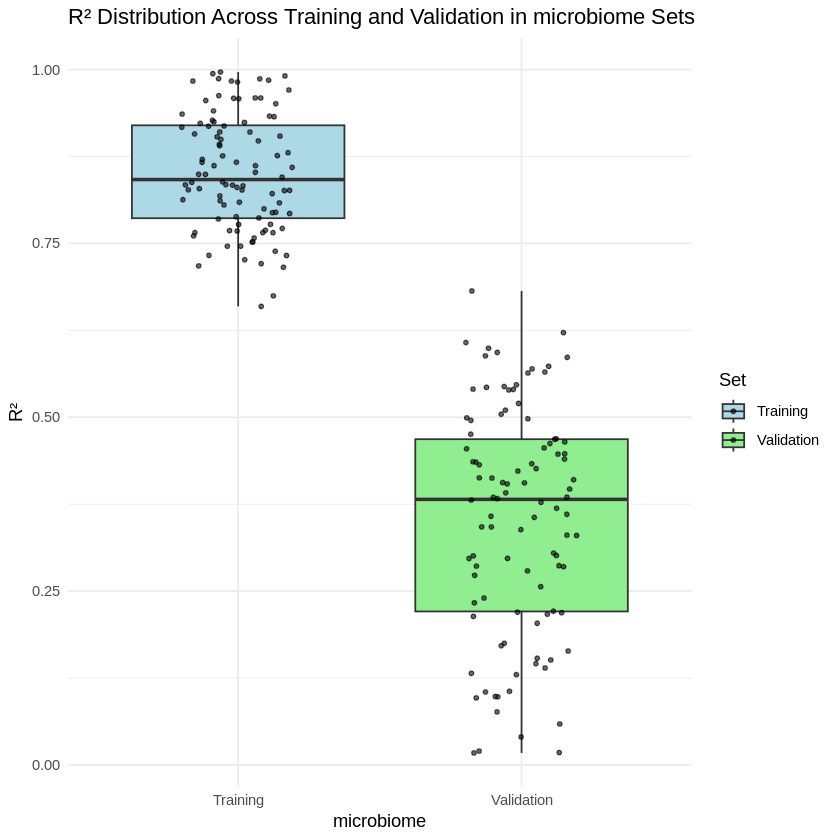

In [15]:
plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)                                            
# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/12_prediction/microbiome_predicition_pvalue_common_select_spearman.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in microbiome Sets",
       x = "microbiome",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
print(g)
# dev.off()    
# print(g)

In [16]:
save.image("/vol/projects/yzhang/500FG_aging/output/10_microbiome/microbiome_prediction_spearman_select_elasticnet.Rdata")